# Klasifikasi Batik - Ekstraksi Fitur GLCM Saja

Notebook ini merupakan bagian dari *Ablation Study* untuk mengevaluasi performa model klasifikasi jika HANYA menggunakan fitur tekstur statistik GLCM (Gray Level Co-occurrence Matrix) tanpa bantuan Deep Learning.


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns


In [2]:
TRAIN_DIR = 'dataset/train'
TEST_DIR = 'dataset/test'

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl, a, b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2BGR)
    return final_img

def extract_glcm_features(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    distances = [1]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
    glcm = graycomatrix(gray, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    ASM = graycoprops(glcm, 'ASM').mean()
    
    return [contrast, dissimilarity, homogeneity, energy, correlation, ASM]


In [3]:
def process_dataset(directory, augment_rotation=False):
    features = []
    labels = []
    classes = sorted([d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))])
    
    for class_name in tqdm(classes, desc=f"Processing {directory}"):
        class_dir = os.path.join(directory, class_name)
        for img_name in os.listdir(class_dir):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            
            img_clahe = apply_clahe(img)
            rotations = [None]
            if augment_rotation:
                rotations.extend([cv2.ROTATE_90_CLOCKWISE, cv2.ROTATE_180, cv2.ROTATE_90_COUNTERCLOCKWISE])
                
            for rot in rotations:
                try:
                    img_processed = cv2.rotate(img_clahe, rot) if rot is not None else img_clahe
                    glcm_feats = extract_glcm_features(img_processed)
                    features.append(glcm_feats)
                    labels.append(class_name)
                except Exception as e:
                    pass
    return np.array(features), np.array(labels)

X_train, y_train_raw = process_dataset(TRAIN_DIR, augment_rotation=True)
X_test, y_test_raw = process_dataset(TEST_DIR, augment_rotation=False)


Processing dataset/test: 100%|██████████| 20/20 [00:17<00:00,  1.13it/s]


In [4]:
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dimensi fitur GLCM: {X_train_scaled.shape[1]}")


Dimensi fitur GLCM: 6


## Evaluasi Multi-Model (Ablation GLCM)

In [5]:
models = {
    "SVM": {
        "model": SVC(C=10, kernel='rbf', probability=True, random_state=42),
        "param_info": "C=10, kernel='rbf'"
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(n_neighbors=3, weights='distance'),
        "param_info": "n_neighbors=3, weights='distance'"
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42),
        "param_info": "n_estimators=100, max_depth=20"
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=None, random_state=42),
        "param_info": "max_depth=None"
    },
    "Dense Neural Network (MLP)": {
        "model": MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=500, random_state=42),
        "param_info": "hidden_layers=(256, 128), max_iter=500"
    }
}

results = {}

for name, info in models.items():
    print(f"Melatih model {name} (GLCM Saja)...")
    model = info["model"]
    
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    end_train = time.time()
    
    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    end_pred = time.time()
    
    acc = accuracy_score(y_test, y_pred)
    train_time = end_train - start_train
    pred_time = end_pred - start_pred
    
    results[name] = {
        'accuracy': acc,
        'predictions': y_pred,
        'train_time': train_time,
        'pred_time': pred_time,
        'param_info': info["param_info"]
    }
    
    print(f"-> Waktu Latih: {train_time:.4f} detik | Waktu Prediksi: {pred_time:.4f} detik")
    print(f"-> Selesai! Akurasi: {acc * 100:.2f}%\n")


Melatih model SVM (GLCM Saja)...
-> Waktu Latih: 5.4882 detik | Waktu Prediksi: 0.1186 detik
-> Selesai! Akurasi: 31.56%

Melatih model K-Nearest Neighbors (GLCM Saja)...
-> Waktu Latih: 0.0096 detik | Waktu Prediksi: 0.0116 detik
-> Selesai! Akurasi: 38.44%

Melatih model Random Forest (GLCM Saja)...
-> Waktu Latih: 1.0156 detik | Waktu Prediksi: 0.0197 detik
-> Selesai! Akurasi: 39.06%

Melatih model Decision Tree (GLCM Saja)...
-> Waktu Latih: 0.0242 detik | Waktu Prediksi: 0.0000 detik
-> Selesai! Akurasi: 30.00%

Melatih model Dense Neural Network (MLP) (GLCM Saja)...
-> Waktu Latih: 96.4172 detik | Waktu Prediksi: 0.0025 detik
-> Selesai! Akurasi: 36.88%



TABEL PERBANDINGAN MODEL KLASIFIKASI BATIK (GLCM SAJA)


,Model,Akurasi (%),Waktu Latih (detik),Waktu Prediksi (detik),Parameter Terbaik
0,SVM,31.56,5.4882,0.1186,"C=10, kernel='rbf'"
1,K-Nearest Neighbors,38.44,0.0096,0.0116,"n_neighbors=3, weights='distance'"
2,Random Forest,39.06,1.0156,0.0197,"n_estimators=100, max_depth=20"
3,Decision Tree,30.00,0.0242,0.0000,max_depth=None
4,Dense Neural Network (MLP),36.88,96.4172,0.0025,"hidden_layers=(256, 128), max_iter=500"





EVALUASI MODEL: SVM

--- Classification Report (SVM) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.00      0.00      0.00        16
               Bali_Barong       0.33      0.06      0.11        16
                Bali_Merak       0.41      0.44      0.42        16
           DKI_Ondel_Ondel       0.24      0.25      0.24        16
     JawaBarat_Megamendung       0.42      0.50      0.46        16
           JawaTimur_Pring       0.19      0.19      0.19        16
          Kalimantan_Dayak       0.67      0.75      0.71        16
             Lampung_Gajah       0.33      0.38      0.35        16
        Madura_Mataketeran       0.83      0.31      0.45        16
               Maluku_Pala       0.45      0.31      0.37        16
               NTB_Lumbung       0.12      0.12      0.12        16
               Papua_Asmat       0.18      0.12      0.15        16
         Papua_Cendrawasih       0.80      0.50      0.

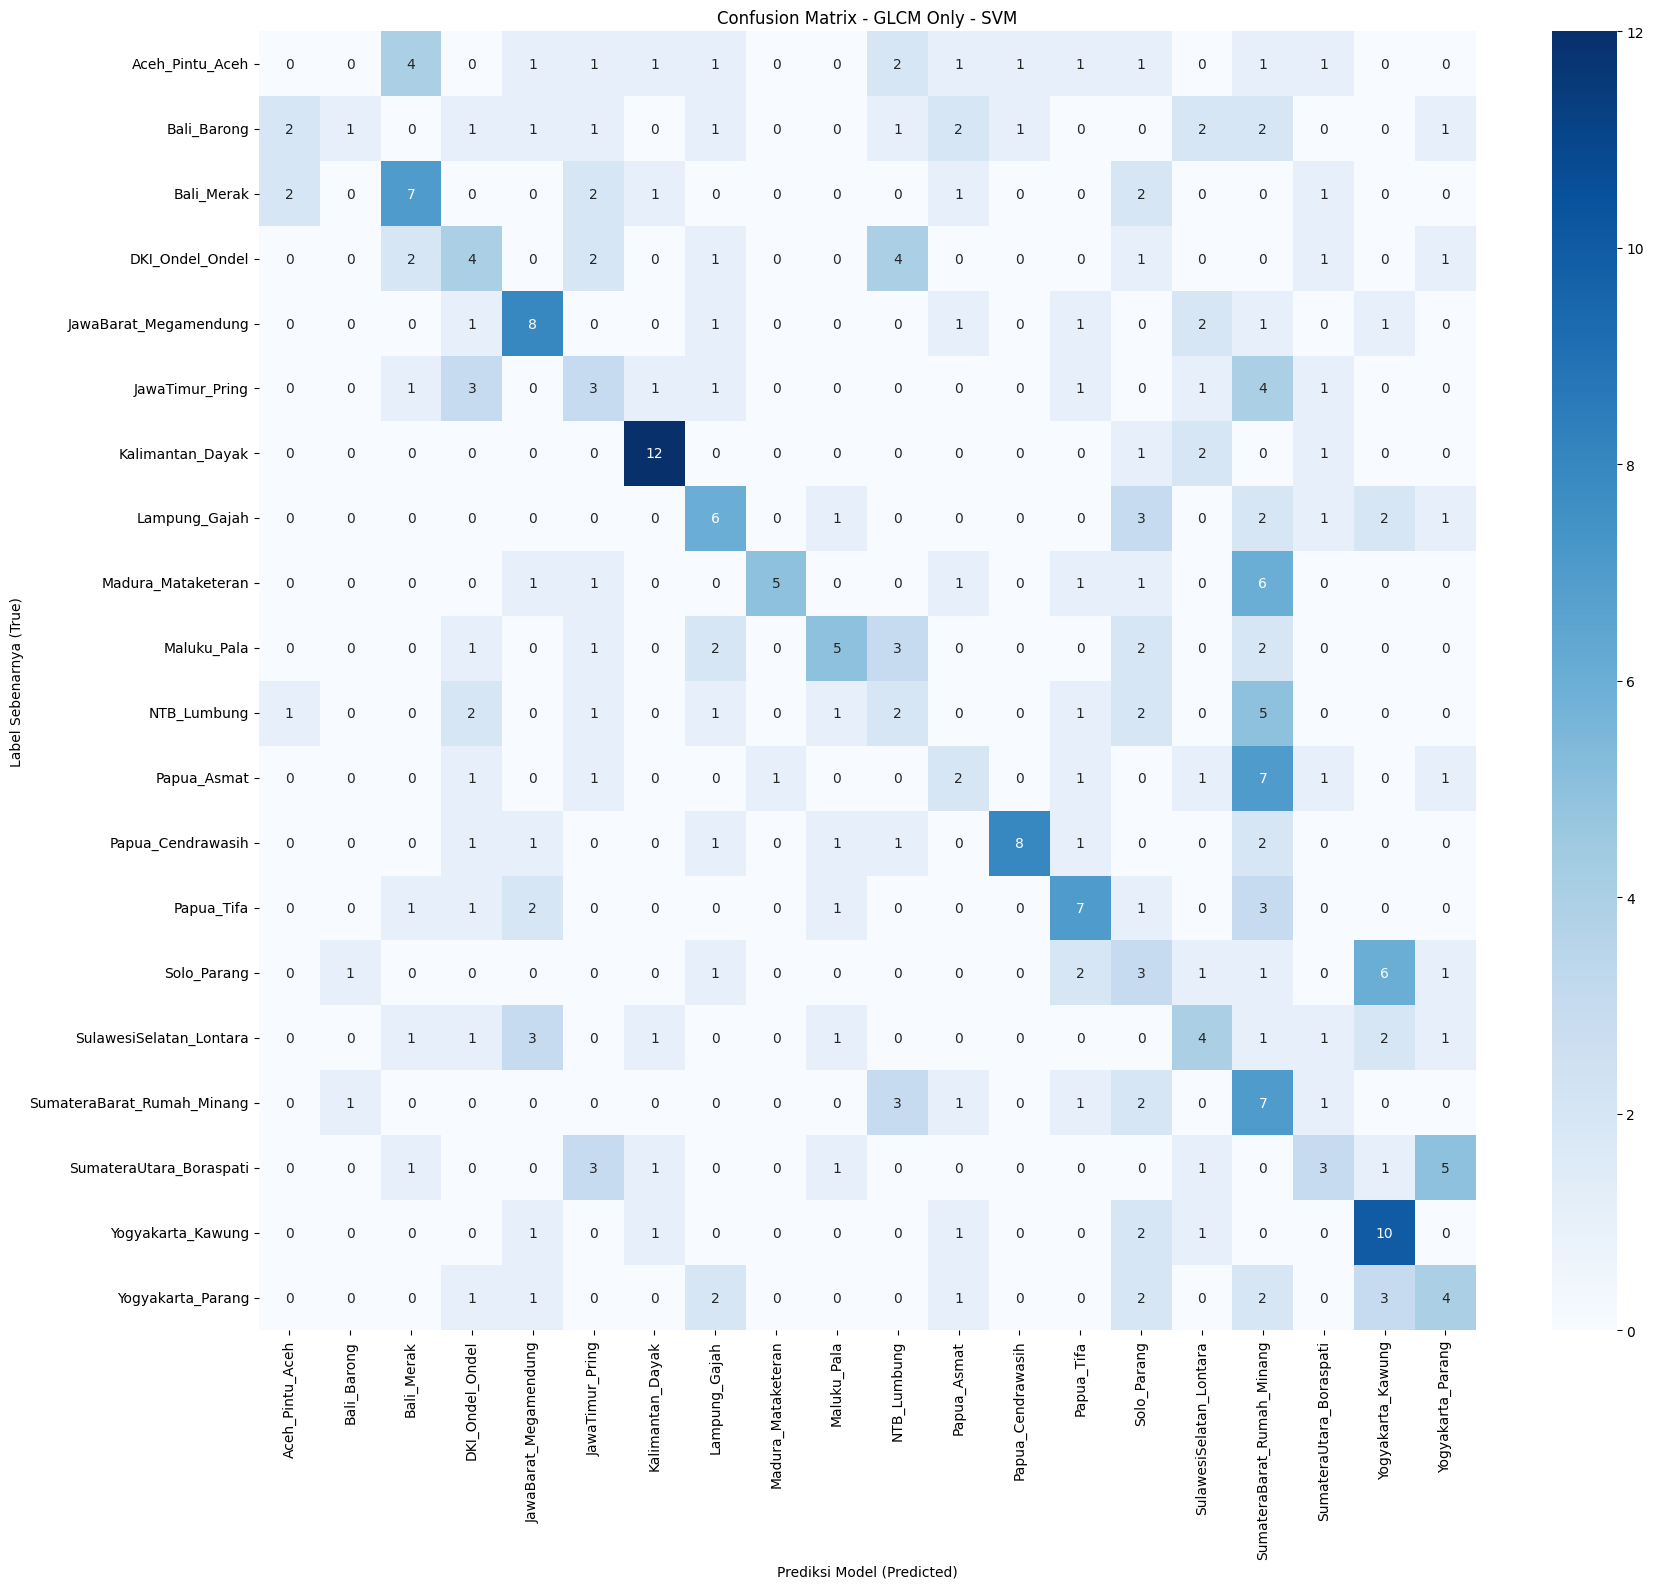


EVALUASI MODEL: K-Nearest Neighbors

--- Classification Report (K-Nearest Neighbors) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.25      0.25      0.25        16
               Bali_Barong       0.09      0.06      0.07        16
                Bali_Merak       0.57      0.75      0.65        16
           DKI_Ondel_Ondel       0.36      0.25      0.30        16
     JawaBarat_Megamendung       0.31      0.25      0.28        16
           JawaTimur_Pring       0.08      0.06      0.07        16
          Kalimantan_Dayak       0.57      0.75      0.65        16
             Lampung_Gajah       0.47      0.44      0.45        16
        Madura_Mataketeran       0.43      0.56      0.49        16
               Maluku_Pala       0.43      0.38      0.40        16
               NTB_Lumbung       0.33      0.25      0.29        16
               Papua_Asmat       0.40      0.38      0.39        16
         Papua_Cendrawasi

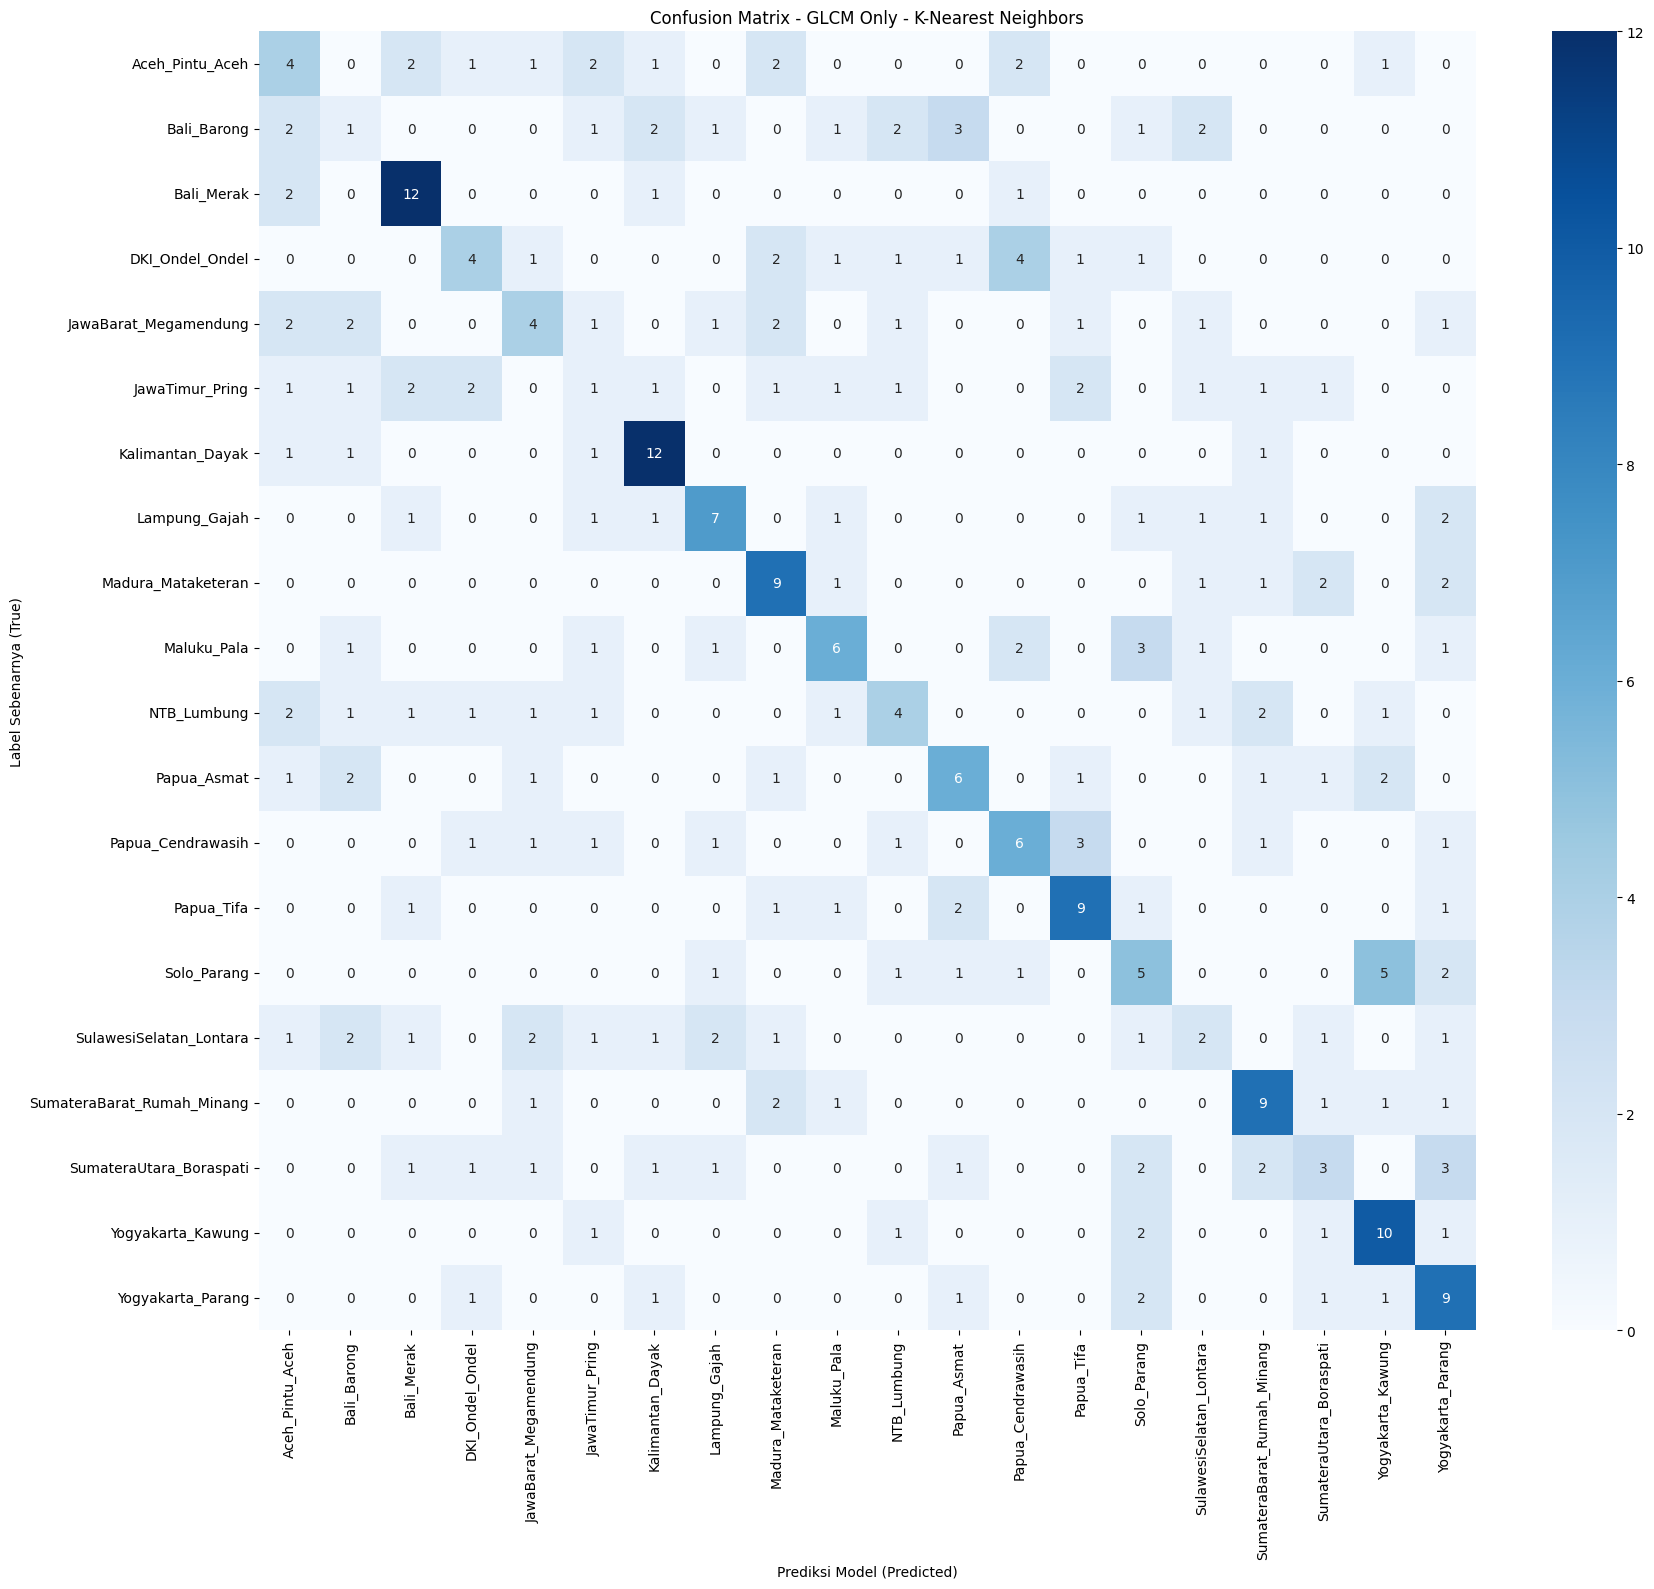


EVALUASI MODEL: Random Forest

--- Classification Report (Random Forest) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.29      0.25      0.27        16
               Bali_Barong       0.17      0.12      0.14        16
                Bali_Merak       0.61      0.69      0.65        16
           DKI_Ondel_Ondel       0.33      0.31      0.32        16
     JawaBarat_Megamendung       0.20      0.25      0.22        16
           JawaTimur_Pring       0.11      0.06      0.08        16
          Kalimantan_Dayak       0.56      0.88      0.68        16
             Lampung_Gajah       0.44      0.44      0.44        16
        Madura_Mataketeran       0.57      0.50      0.53        16
               Maluku_Pala       0.58      0.44      0.50        16
               NTB_Lumbung       0.44      0.44      0.44        16
               Papua_Asmat       0.35      0.50      0.41        16
         Papua_Cendrawasih       0.45

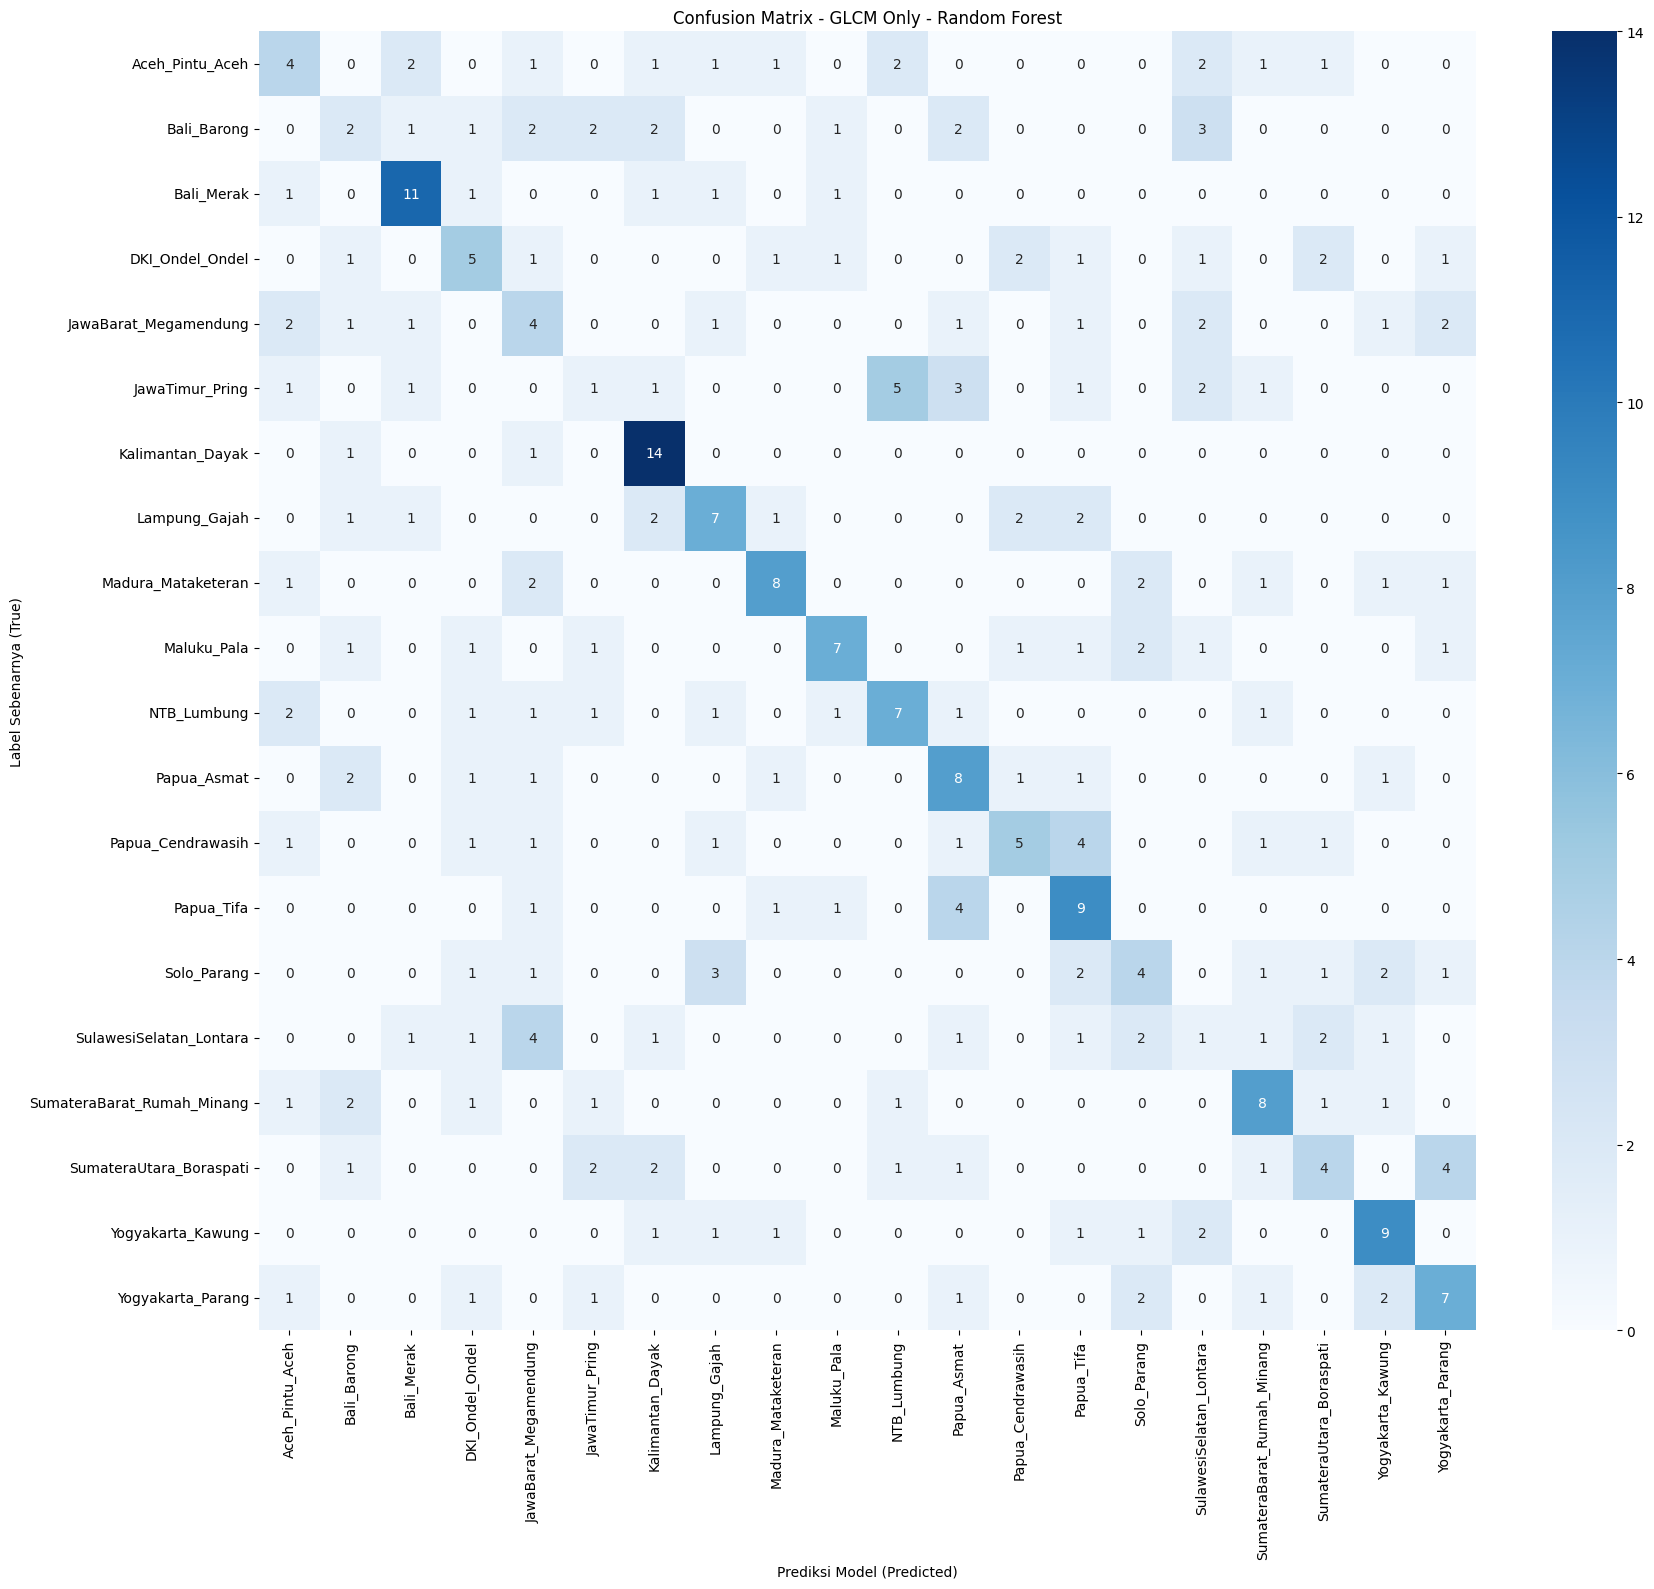


EVALUASI MODEL: Decision Tree

--- Classification Report (Decision Tree) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.21      0.19      0.20        16
               Bali_Barong       0.20      0.19      0.19        16
                Bali_Merak       0.53      0.62      0.57        16
           DKI_Ondel_Ondel       0.33      0.25      0.29        16
     JawaBarat_Megamendung       0.19      0.31      0.24        16
           JawaTimur_Pring       0.08      0.06      0.07        16
          Kalimantan_Dayak       0.48      0.62      0.54        16
             Lampung_Gajah       0.20      0.25      0.22        16
        Madura_Mataketeran       0.45      0.31      0.37        16
               Maluku_Pala       0.38      0.38      0.38        16
               NTB_Lumbung       0.42      0.31      0.36        16
               Papua_Asmat       0.30      0.38      0.33        16
         Papua_Cendrawasih       0.27

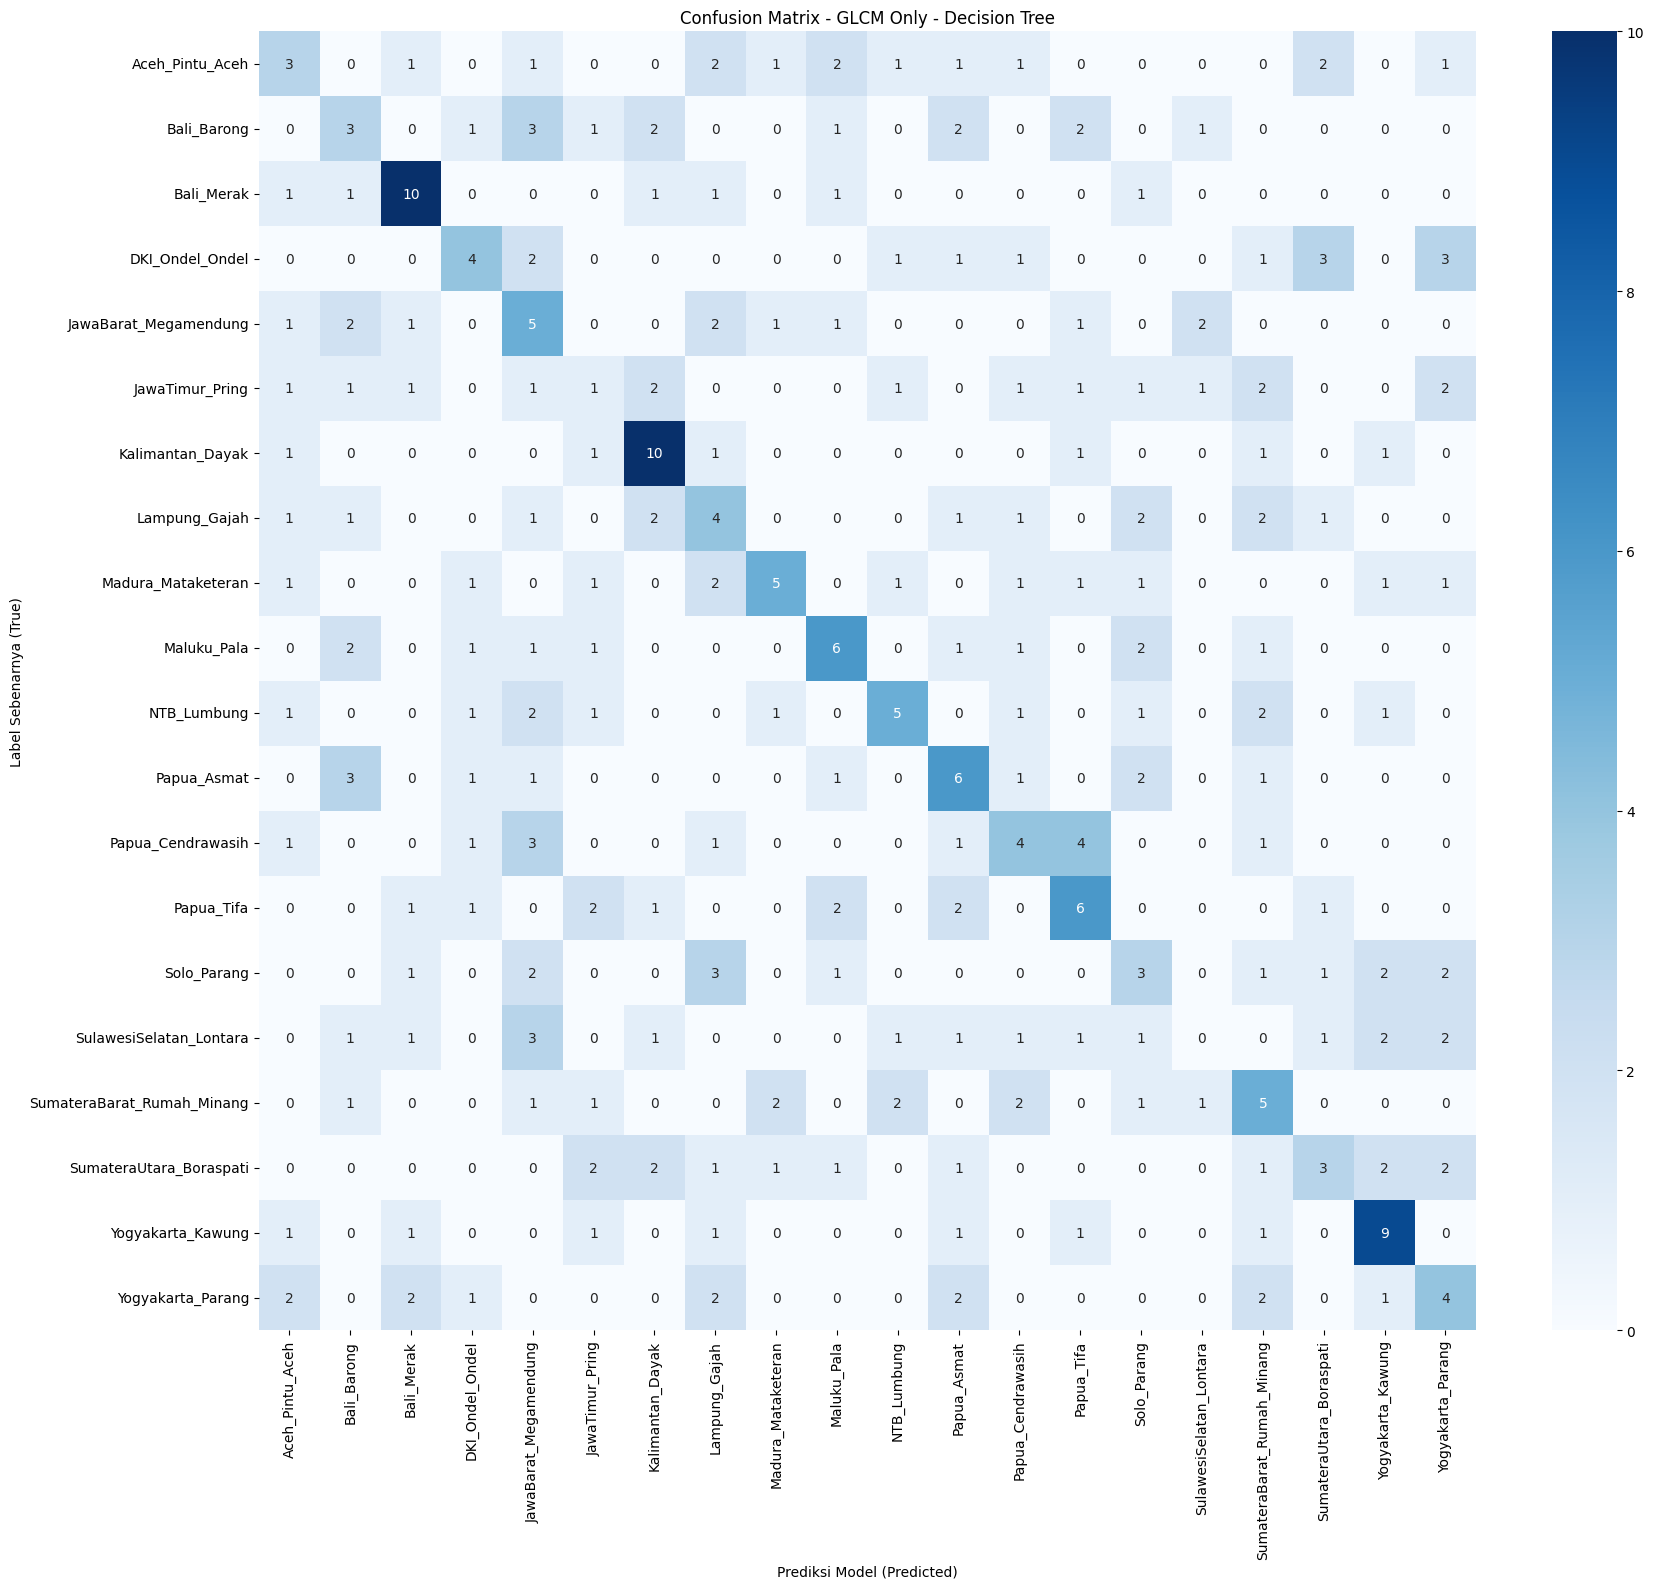


EVALUASI MODEL: Dense Neural Network (MLP)

--- Classification Report (Dense Neural Network (MLP)) ---
                            precision    recall  f1-score   support

           Aceh_Pintu_Aceh       0.15      0.12      0.14        16
               Bali_Barong       0.36      0.25      0.30        16
                Bali_Merak       0.59      0.81      0.68        16
           DKI_Ondel_Ondel       0.15      0.12      0.14        16
     JawaBarat_Megamendung       0.40      0.38      0.39        16
           JawaTimur_Pring       0.30      0.19      0.23        16
          Kalimantan_Dayak       0.54      0.88      0.67        16
             Lampung_Gajah       0.45      0.56      0.50        16
        Madura_Mataketeran       0.67      0.38      0.48        16
               Maluku_Pala       0.56      0.62      0.59        16
               NTB_Lumbung       0.24      0.25      0.24        16
               Papua_Asmat       0.22      0.25      0.24        16
         Pa

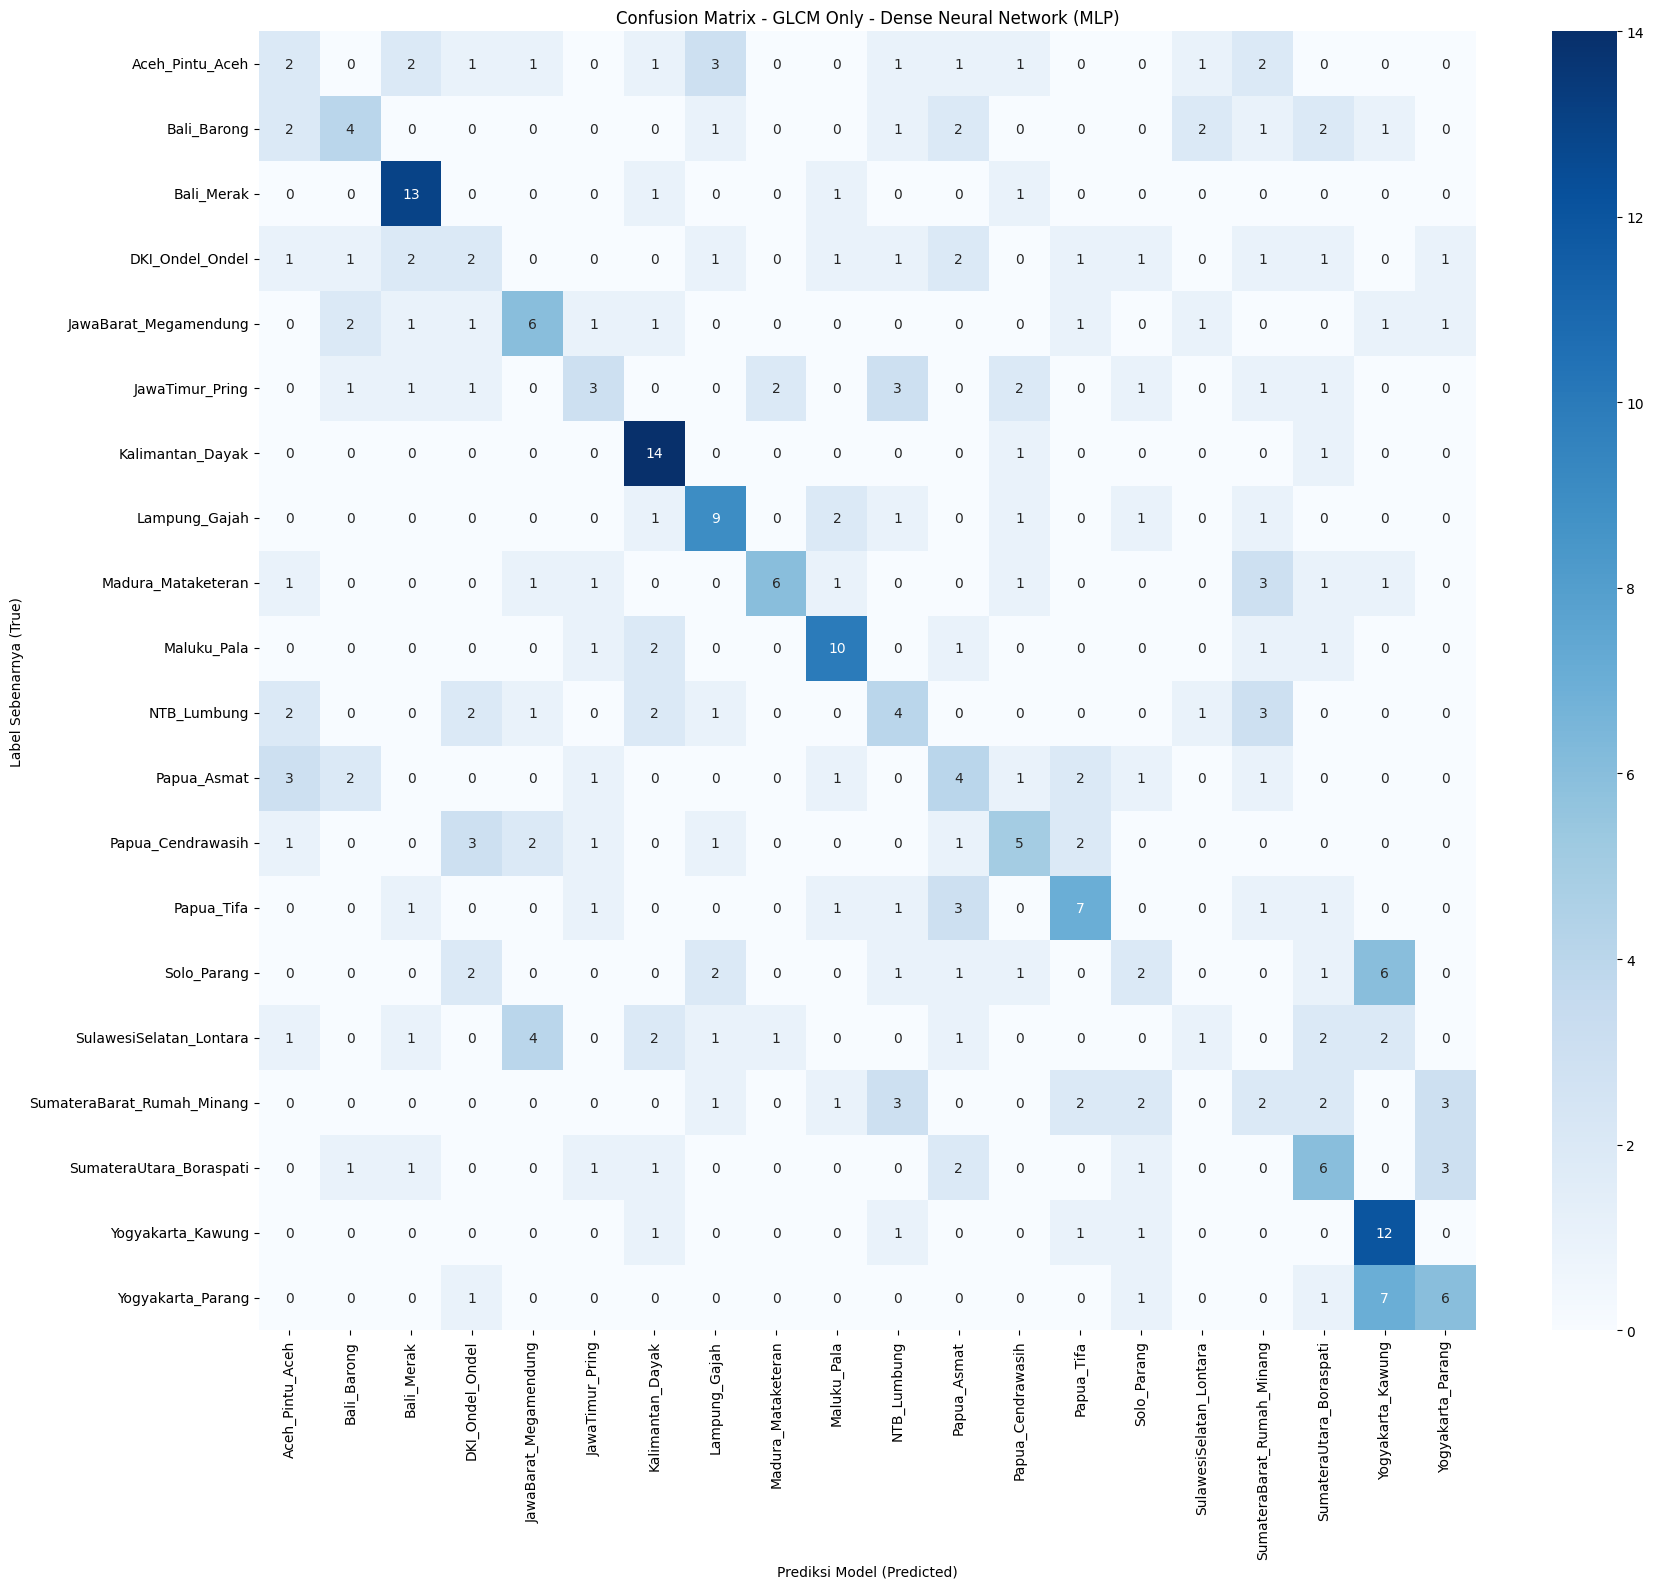

In [6]:
comparison_data = []
for name, res in results.items():
    comparison_data.append({
        "Model": name,
        "Akurasi (%)": round(res['accuracy'] * 100, 2),
        "Waktu Latih (detik)": round(res['train_time'], 4),
        "Waktu Prediksi (detik)": round(res['pred_time'], 4),
        "Parameter Terbaik": res['param_info']
    })

df_compare = pd.DataFrame(comparison_data)
print("=========================================================================================")
print("TABEL PERBANDINGAN MODEL KLASIFIKASI BATIK (GLCM SAJA)")
print("=========================================================================================")
display(df_compare)
print("\n")

for name, res in results.items():
    print(f"\n{'='*50}")
    print(f"EVALUASI MODEL: {name}")
    print(f"{'='*50}")
    
    print(f"\n--- Classification Report ({name}) ---")
    print(classification_report(y_test, res['predictions'], target_names=le.classes_))
    
    cm = confusion_matrix(y_test, res['predictions'])
    
    plt.figure(figsize=(18, 16))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - GLCM Only - {name}')
    plt.ylabel('Label Sebenarnya (True)')
    plt.xlabel('Prediksi Model (Predicted)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
